--- TEST 1: Claim Type vs. Reframing ---
Reframing Frequency (% of replies that reframe):
generic
Generic     51.66%
Specific    29.98%
Name: True, dtype: object
Chi-Square p-value: 0.0000

--- TEST 2: Community Type vs. Reframing ---
Reframing Frequency (% of replies that reframe):
subreddit_type
general     39.74%
specific    40.86%
Name: True, dtype: object
Chi-Square p-value: 0.6901

✅ Analysis complete. Visualization saved as 'reframing_paradox_analysis.png'


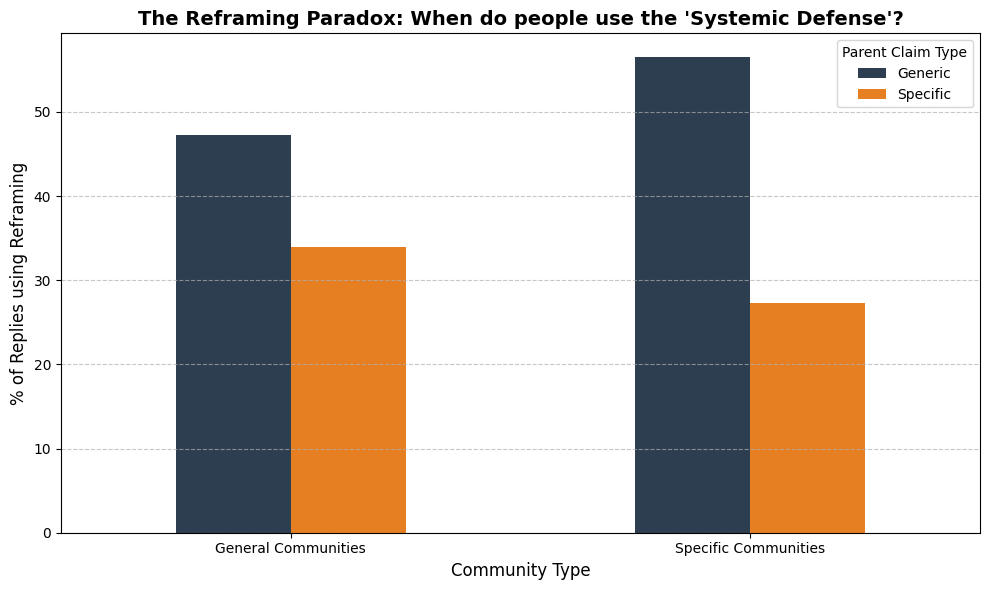

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv('/kaggle/input/notebooks/ianaaa/chat-gpt-annotating/generational_stereotypes_full_run.csv')

# 1. ANALYSIS: Does Claim Style (Generic vs Specific) affect Reframing?
claim_subset = df[df['generic'].isin(['Generic', 'Specific'])]
ct_reframing = pd.crosstab(claim_subset['generic'], claim_subset['reframing'])
chi2_r, p_r, _, _ = chi2_contingency(ct_reframing)

# 2. ANALYSIS: Does Community Type affect Reframing?
ct_comm_reframing = pd.crosstab(df['subreddit_type'], df['reframing'])
chi2_c, p_c, _, _ = chi2_contingency(ct_comm_reframing)

# 3. STATISTICAL REPORT
print("--- TEST 1: Claim Type vs. Reframing ---")
print("Reframing Frequency (% of replies that reframe):")
print((ct_reframing.div(ct_reframing.sum(1), axis=0) * 100)[True].round(2).astype(str) + '%')
print(f"Chi-Square p-value: {p_r:.4f}")

print("\n--- TEST 2: Community Type vs. Reframing ---")
print("Reframing Frequency (% of replies that reframe):")
print((ct_comm_reframing.div(ct_comm_reframing.sum(1), axis=0) * 100)[True].round(2).astype(str) + '%')
print(f"Chi-Square p-value: {p_c:.4f}")

# 4. VISUALIZATION: The Interaction
# We look at Reframing % split by both Community AND Claim Type
plt.figure(figsize=(10, 6))
interaction = df.groupby(['subreddit_type', 'generic'])['reframing'].mean() * 100
interaction_df = interaction.unstack()

interaction_df.index = ['General Communities', 'Specific Communities']
interaction_df = interaction_df[['Generic', 'Specific']] # Focus on the main two

interaction_df.plot(kind='bar', color=['#2c3e50', '#e67e22'], ax=plt.gca())
plt.title("The Reframing Paradox: When do people use the 'Systemic Defense'?", fontsize=14, fontweight='bold')
plt.ylabel("% of Replies using Reframing", fontsize=12)
plt.xlabel("Community Type", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Parent Claim Type", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('reframing_paradox_analysis.png')
print("\n✅ Analysis complete. Visualization saved as 'reframing_paradox_analysis.png'")

Total Reframed Pairs Analyzed: 632

--- Top 5 Reframing 'Destinations' ---
reply_frame_heuristic
Family_life       25.158228
Health_aging      20.727848
Other/Systemic    18.196203
Tech_media        14.715190
Work_economy      11.392405
Name: proportion, dtype: float64

✅ Matrix saved as 'reframing_direction_matrix.png'


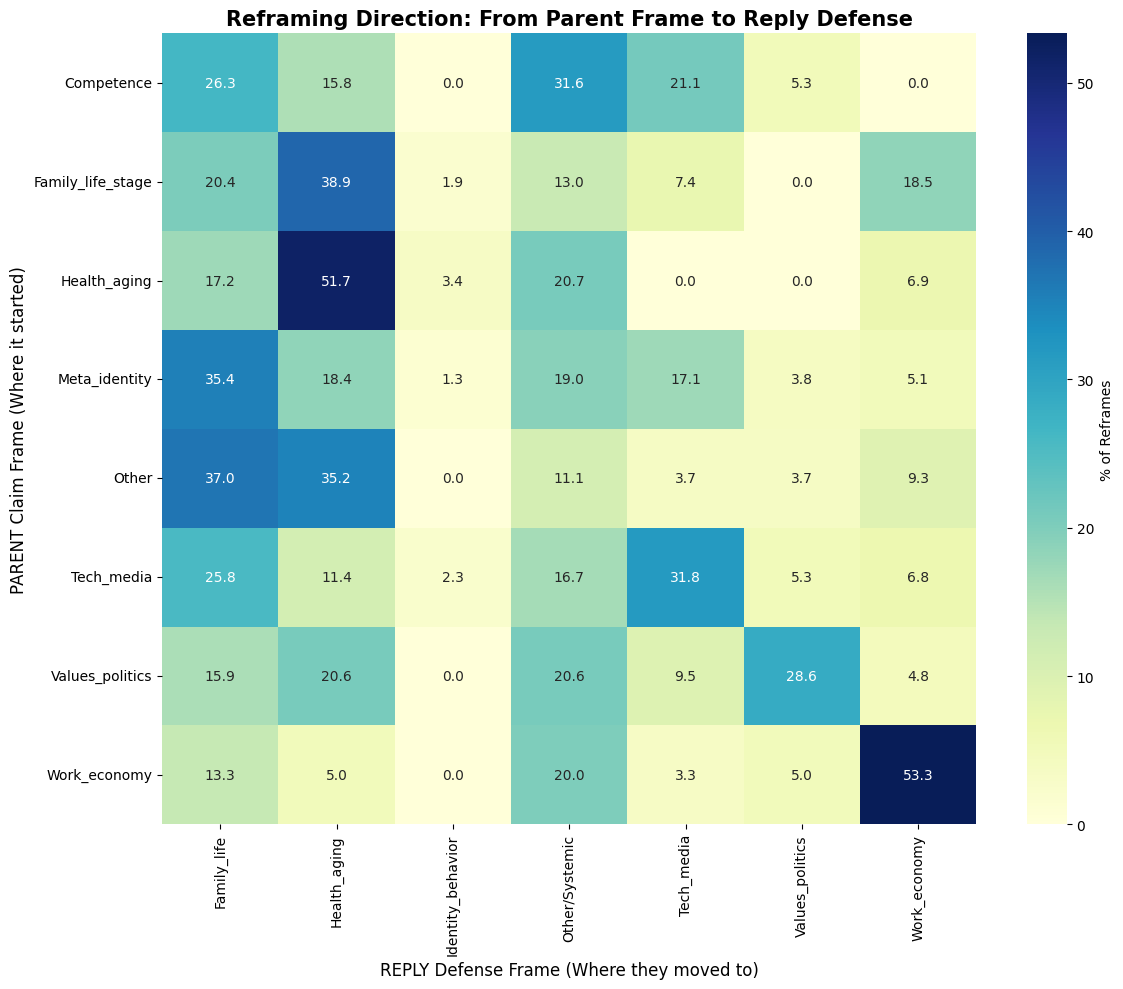

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/notebooks/ianaaa/chat-gpt-annotating/generational_stereotypes_full_run.csv')

# 1. Filter only for cases where Reframing happened
reframed_df = df[df['reframing'] == True].copy()

# 2. Define a simple keyword heuristic to identify the "Reply Frame" from the reasoning
frame_keywords = {
    'Work_economy': ['economy', 'finance', 'housing', 'money', 'inflation', 'cost', 'wage', 'work', 'job', 'labor', 'market'],
    'Tech_media': ['tech', 'internet', 'social media', 'computer', 'technology', 'phone', 'typing', 'online'],
    'Health_aging': ['health', 'age', 'aging', 'mental', 'physical', 'covid', 'illness', 'medicine'],
    'Values_politics': ['politic', 'value', 'maga', 'liberal', 'conservative', 'vote', 'religion', 'belief'],
    'Family_life': ['family', 'parent', 'children', 'marriage', 'home', 'lifestyle'],
    'Identity_behavior': ['identity', 'behavior', 'personality', 'trait', 'lazy', 'entitled', 'attitude', 'culture']
}

def detect_reply_frame(reasoning):
    reasoning = str(reasoning).lower()
    if 'reframing' in reasoning:
        parts = reasoning.split('reframing')
        target_text = parts[-1]
    else:
        target_text = reasoning

    for frame, keywords in frame_keywords.items():
        if any(word in target_text for word in keywords):
            return frame
    return "Other/Systemic"

# heuristic
reframed_df['reply_frame_heuristic'] = reframed_df['reasoning'].apply(detect_reply_frame)

# 3. the Transition Matrix (Parent Frame -> Reply Frame)
transition_matrix = pd.crosstab(reframed_df['frame'], reframed_df['reply_frame_heuristic'], normalize='index') * 100

# 4. STATISTICAL SUMMARY
print(f"Total Reframed Pairs Analyzed: {len(reframed_df)}")
print("\n--- Top 5 Reframing 'Destinations' ---")
print(reframed_df['reply_frame_heuristic'].value_counts(normalize=True).head(5) * 100)

# 5. VISUALIZATION
plt.figure(figsize=(12, 10))
sns.heatmap(transition_matrix, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% of Reframes'})
plt.title("Reframing Direction: From Parent Frame to Reply Defense", fontsize=15, fontweight='bold')
plt.xlabel("REPLY Defense Frame (Where they moved to)", fontsize=12)
plt.ylabel("PARENT Claim Frame (Where it started)", fontsize=12)

plt.tight_layout()
plt.savefig('reframing_direction_matrix.png')
print("\n✅ Matrix saved as 'reframing_direction_matrix.png'")